In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import dabl as dbl
%matplotlib inline

In [2]:
testdata=pd.read_csv("/home/nihal/Desktop/Classification/titanic/train.csv")
traindata=pd.read_csv('/home/nihal/Desktop/Classification/titanic/train.csv')
data =[traindata,testdata]

In [3]:
testdata.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
traindata.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
traindata.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
dbl.detect_types(traindata)

/home/nihal/Desktop/Classification/.venv/lib/python3.14/site-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
/home/nihal/Desktop/Classification/.venv/lib/python3.14/site-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
/home/nihal/Desktop/Classification/.venv/lib/python3.14/site-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
/home/nihal/Desktop/Classification/.venv/lib/python3.14/site-packag

,continuous,dirty_float,low_card_int_ordinal,low_card_int_categorical,categorical,date,free_string,useless
PassengerId,False,False,False,False,False,False,False,True
Survived,False,False,False,False,True,False,False,False
Pclass,False,False,False,False,True,False,False,False
Name,False,False,False,False,False,False,True,False
Sex,False,False,False,False,True,False,False,False
Age,True,False,False,False,False,False,False,False
SibSp,False,False,True,False,False,False,False,False
Parch,False,False,True,False,False,False,False,False
Ticket,False,False,False,False,False,False,True,False
Fare,True,False,False,False,False,False,False,False


In [7]:
traindata.isnull().mean().mul(100).sort_values()


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.224467
Age            19.865320
Cabin          77.104377
dtype: float64

In [8]:
traindata=traindata.drop(columns="Cabin")

In [9]:
traindata["Age"]=traindata["Age"].fillna(traindata["Age"].mean())

In [10]:
traindata["Embarked"]=traindata["Embarked"].fillna(traindata["Embarked"].mode()[0])

In [11]:
type(traindata)

pandas.DataFrame

In [12]:
traindata.isnull().mean().mul(100).sort_values()


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [13]:
testdata.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
testdata.isnull().mean().mul(100).sort_values()

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.224467
Age            19.865320
Cabin          77.104377
dtype: float64

In [15]:
testdata=testdata.drop(columns="Cabin")

In [16]:
testdata["Age"]=testdata["Age"].fillna(testdata["Age"].mean())

In [17]:
testdata["Fare"]=testdata["Fare"].fillna(testdata["Fare"].mode()[0])

In [18]:
testdata.isnull().mean().mul(100).sort_values()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Embarked       0.224467
dtype: float64

In [19]:
sns.set_theme()
num_cols=traindata.select_dtypes("number").columns
cat_cols=traindata.select_dtypes("object").columns
target=traindata["Survived"]
num_cols


/tmp/ipykernel_15785/505942787.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=traindata.select_dtypes("object").columns


Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [20]:
cat_cols

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

<Axes: xlabel='Survived', ylabel='count'>

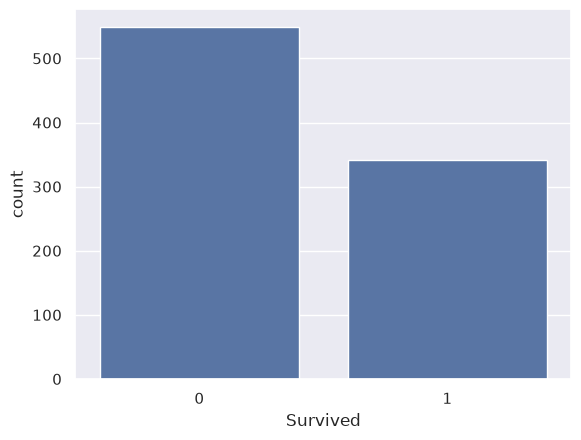

In [21]:
sns.countplot(x=target,data=traindata)

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

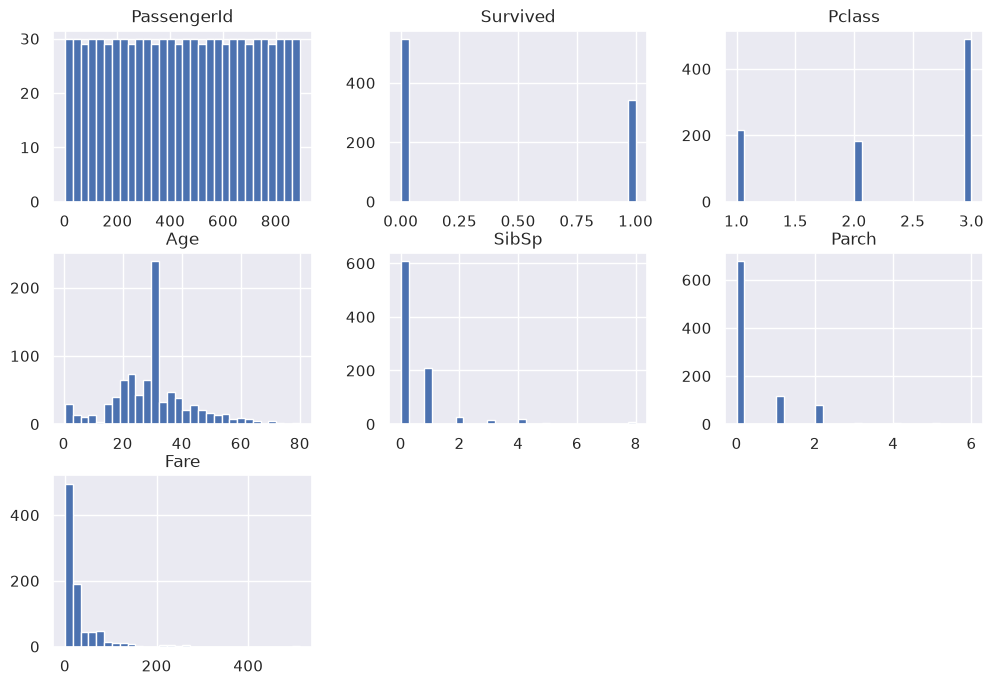

In [22]:
traindata[num_cols].hist(figsize=(12,8),bins=30)

<Axes: xlabel='Age', ylabel='Count'>

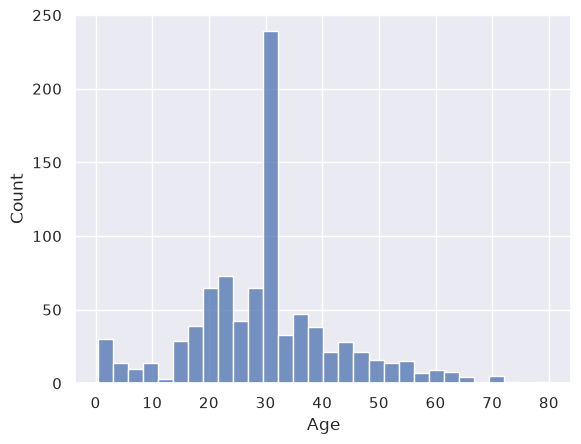

In [23]:
sns.histplot(traindata,x="Age",bins=30)

<Axes: xlabel='Fare', ylabel='Count'>

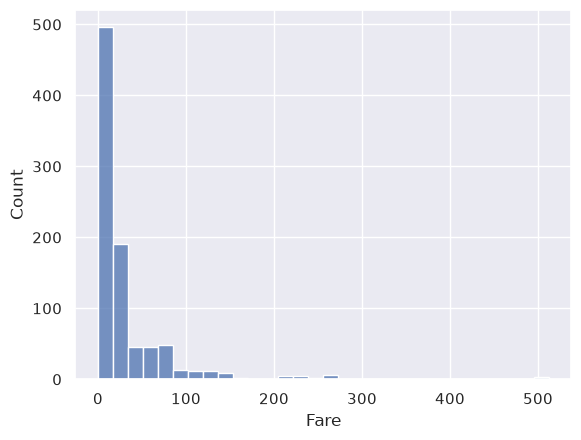

In [24]:
sns.histplot(traindata,x="Fare",bins=30)

<Axes: xlabel='Sex', ylabel='count'>

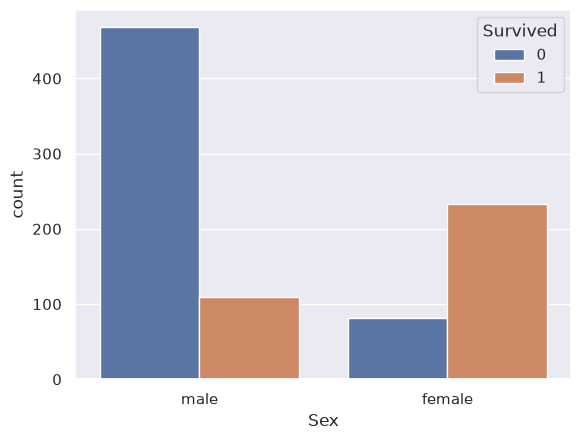

In [25]:
sns.countplot(x="Sex",hue="Survived",data=traindata)

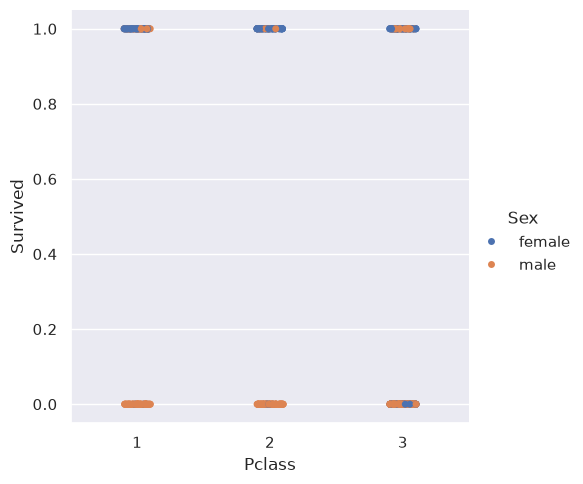

In [26]:
sns.catplot(x="Pclass",y="Survived",hue="Sex",data=traindata)

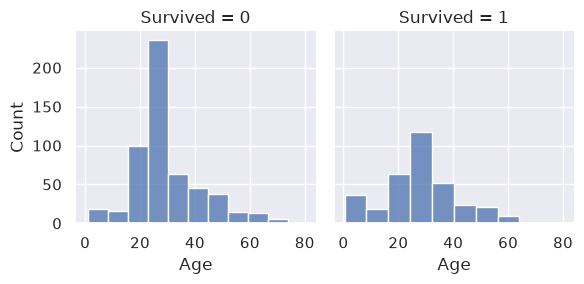

In [27]:
k=sns.FacetGrid(traindata,col='Survived')
k.map(sns.histplot,"Age",bins=10)

In [28]:
traindata.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [29]:
traindata["Title"]=traindata.Name.str.extract(r' ([A-Za-z]+)\.')


In [30]:
traindata["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

<Axes: xlabel='Title', ylabel='Survived'>

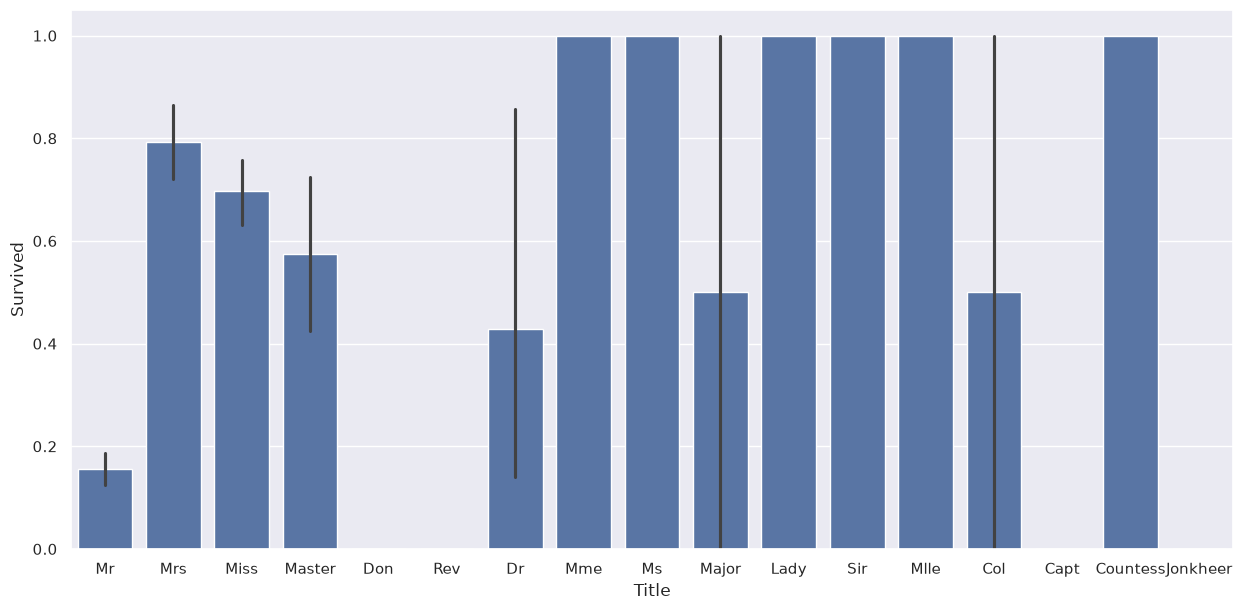

In [31]:
plt.figure(figsize=(15,7))
sns.barplot(x="Title",y="Survived",data=traindata)

In [32]:
traindata=traindata.drop(columns=["Ticket","PassengerId","Name"])

In [33]:
traindata["Sex"]=traindata["Sex"].map({"male":0,"female":1})
traindata=pd.get_dummies(traindata,columns=["Embarked","Title"],drop_first=True)

In [34]:
traindata.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Sex             891 non-null    int64  
 3   Age             891 non-null    float64
 4   SibSp           891 non-null    int64  
 5   Parch           891 non-null    int64  
 6   Fare            891 non-null    float64
 7   Embarked_Q      891 non-null    bool   
 8   Embarked_S      891 non-null    bool   
 9   Title_Col       891 non-null    bool   
 10  Title_Countess  891 non-null    bool   
 11  Title_Don       891 non-null    bool   
 12  Title_Dr        891 non-null    bool   
 13  Title_Jonkheer  891 non-null    bool   
 14  Title_Lady      891 non-null    bool   
 15  Title_Major     891 non-null    bool   
 16  Title_Master    891 non-null    bool   
 17  Title_Miss      891 non-null    bool   
 18  T

In [35]:
x=traindata.drop(columns="Survived")
y=traindata["Survived"]

In [36]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Col,Title_Countess,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,3,0,22.000000,1,0,7.2500,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
1,1,1,38.000000,1,0,71.2833,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,3,1,26.000000,0,0,7.9250,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
3,1,1,35.000000,1,0,53.1000,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,3,0,35.000000,0,0,8.0500,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,13.0000,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
887,1,1,19.000000,0,0,30.0000,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
888,3,1,29.699118,1,2,23.4500,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
889,1,0,26.000000,0,0,30.0000,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [37]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64